# European Steel Decarbonization
## Basic Exploratory Data Analysis

**Team:** SuSteelAible  
**Author:** Irene   
**Date:** November 26, 2024  
**Focus:** Process emissions (Scope 1) analysis to understand technology lock-in

---

## 1. Setup & Data Loading

Loading dataset covering 8 European steel companies (2013-2024) with production volumes and emissions data.

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Settings
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
%matplotlib inline

In [2]:
# Load data (tab-delimited for European character compatibility)
df = pd.read_csv('data/Emissions_data.txt', sep='\t', encoding='latin-1')
# Display info
print(f"Dataset: {len(df)} rows, {len(df.columns)} columns")
print(f"Companies: {df['company'].nunique()}")
print(f"Years: {df['year'].min()}-{df['year'].max()}")
df.head()


Dataset: 85 rows, 23 columns
Companies: 9
Years: 2013-2024


,company,country,technology,transformation_tech,year,production,scope1,scope2_location,scope2_market,scope_1_2_location,...,cap_supplier_engagement,ecovadis,ESG_transparency,SBTi_validated,responsible_steel,iso_14001,iso_14064,iso_45001,data_quality,notes
0,ArcelorMittal,Luxembourg,BF-BOF,NaN,2013,90.9,162.0,18.0,NaN,180.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Excellent,Historical portfolio
1,ArcelorMittal,Luxembourg,BF-BOF,NaN,2014,93.4,167.0,14.0,NaN,181.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Excellent,Historical portfolio
2,ArcelorMittal,Luxembourg,BF-BOF,NaN,2015,92.7,168.0,14.0,NaN,182.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Excellent,Historical portfolio
3,ArcelorMittal,Luxembourg,BF-BOF,NaN,2016,90.4,167.0,12.0,NaN,179.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Excellent,Historical portfolio
4,ArcelorMittal,Luxembourg,BF-BOF,NaN,2017,92.9,170.0,13.0,NaN,183.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Excellent,Historical portfolio


In [3]:
# Check data types
print("="*80)
print("DATA TYPES CHECK")
print("="*80)
print("\nCurrent data types:")
print(df.dtypes)
print("\nNo conversion necessary!")

DATA TYPES CHECK

Current data types:
company                     object
country                     object
technology                  object
transformation_tech         object
year                         int64
production                 float64
scope1                     float64
scope2_location            float64
scope2_market              float64
scope_1_2_location         float64
intensity_location_co2e    float64
intensity_market_co2e      float64
cdp_climate_score           object
cap_supplier_engagement     object
ecovadis                    object
ESG_transparency            object
SBTi_validated              object
responsible_steel           object
iso_14001                   object
iso_14064                   object
iso_45001                   object
data_quality                object
notes                       object
dtype: object

No conversion necessary!


## 2. Methodology: Why Scope 1 Only?

**Issue:** Scope 2 methodology varies (location-based vs market-based), creating inconsistencies:  
- Outokumpu: +32% difference (renewable energy contracts)  
- Range across dataset: -39% to +70%

In [4]:
# Compare location-based vs market-based Scope 2
comparison = df[df['scope2_location'].notna() & df['scope2_market'].notna()].copy()
comparison['diff_pct'] = ((comparison['scope2_location'] - comparison['scope2_market']) / 
                          comparison['scope2_location'] * 100)

print(f"Observations with both Scope 2 values: {len(comparison)}")
print(f"Average difference: {comparison['diff_pct'].mean():.1f}%")
print(f"Range: {comparison['diff_pct'].min():.1f}% to {comparison['diff_pct'].max():.1f}%")
print(f"\nBy company:")
print(comparison.groupby('company')['diff_pct'].agg(['count', 'mean']).round(1))

Observations with both Scope 2 values: 15
Average difference: -0.0%
Range: -39.2% to 69.6%

By company:
               count  mean
company                   
Celsa Group        4 -27.7
Outokumpu          3  32.0
Salzgitter AG      2 -10.3
Voestalpine        6   5.9


**Solution:** Analyze **Scope 1 only** (process emissions) for consistency.  
- Always comparable across companies and time
- Shows true technology differences
- Represents ~90% of emissions for BF-BOF (~20% for EAF)

In [5]:
# Create Scope 1 intensity
df['intensity_scope1'] = df['scope1'] / df['production']

# Filter complete observations
df_complete = df[df['intensity_scope1'].notna()].copy()

print(f"Complete Scope 1 data: {len(df_complete)}/{len(df)} observations")
print(f"Companies with Scope 1: {df_complete['company'].nunique()}")

Complete Scope 1 data: 63/85 observations
Companies with Scope 1: 7


## 3. Technology Comparison

Steel production technology is the dominant factor in emissions intensity.

In [6]:
# Statistics by technology
tech_stats = df_complete.groupby('technology')['intensity_scope1'].agg([
    ('n', 'count'),
    ('mean', 'mean'),
    ('std', 'std'),
    ('min', 'min'),
    ('max', 'max')
]).round(3)

print("Scope 1 Intensity by Technology (tCO2e/t):")
print(tech_stats)
tech_stats.to_csv('output_stats_by_technology.csv')

Scope 1 Intensity by Technology (tCO2e/t):
                n   mean    std    min    max
technology                                   
BF-BOF         46  1.657  0.175  1.383  1.874
EAF             5  0.113  0.013  0.098  0.127
EAF Stainless  12  0.467  0.039  0.399  0.529


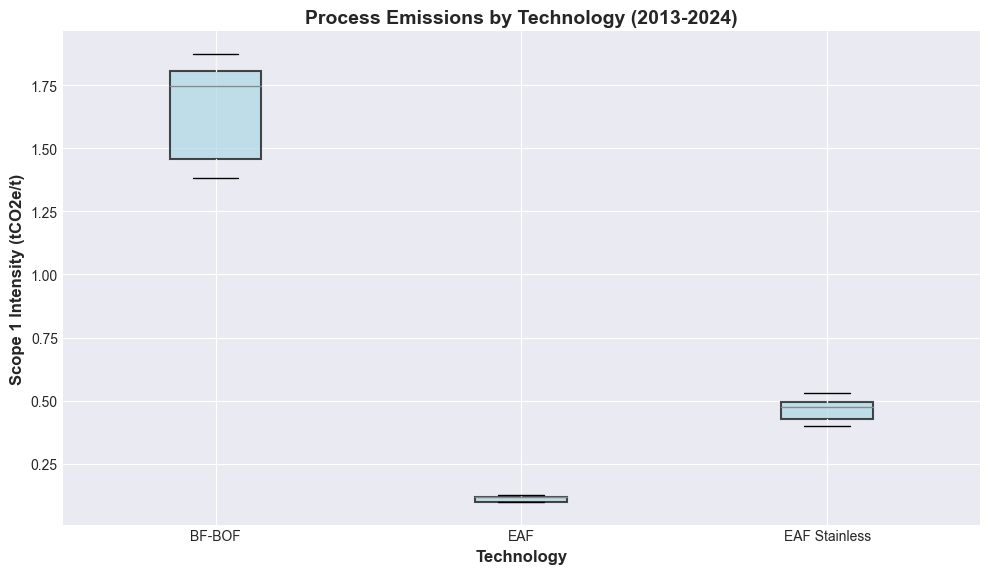

Range: 0.11 - 1.66 tCO2e/t
Difference: 15x


In [7]:
# Boxplot: Technology comparison
fig, ax = plt.subplots(figsize=(10, 6))

# Create boxplot with visible styling
bp = df_complete.boxplot(column='intensity_scope1', by='technology', ax=ax, 
                          patch_artist=True, return_type='dict')

# Make boxes more visible
for patch in ax.patches:
    patch.set_facecolor('lightblue')
    patch.set_alpha(0.7)
    patch.set_edgecolor('black')
    patch.set_linewidth(1.5)

# Labels without subscripts (avoids font warning)
ax.set_xlabel('Technology', fontsize=12, fontweight='bold')
ax.set_ylabel('Scope 1 Intensity (tCO2e/t)', fontsize=12, fontweight='bold')
ax.set_title('Process Emissions by Technology (2013-2024)', fontsize=14, fontweight='bold')
plt.suptitle('')  # Remove auto-title
plt.tight_layout()
plt.savefig('plot1_boxplot_technology.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Range: {tech_stats['mean'].min():.2f} - {tech_stats['mean'].max():.2f} tCO2e/t")
print(f"Difference: {tech_stats['mean'].max()/tech_stats['mean'].min():.0f}x")

## 4. Trend Analysis: Are Companies Improving?

Linear regression for each company to detect temporal trends in process emissions.

In [8]:
# Calculate trends
trends = []

for company in df_complete['company'].unique():  # Loop through each unique company in the dataset
    company_df = df_complete[df_complete['company'] == company].sort_values('year') # Filter data to only this company's rows, then sort by year
    
    # Filter valid data - check which rows have BOTH year AND intensity_scope1 
    valid_rows = company_df[['year', 'intensity_scope1']].notna().all(axis=1)
    company_clean = company_df[valid_rows]
    
    if len(company_clean) >= 3: # Only calculate trend if we have at least 3 data points
        x = company_clean['year'].values.astype(float)
        y = company_clean['intensity_scope1'].values.astype(float)
        
        if not (np.any(np.isnan(x)) or np.any(np.isnan(y))): 
            # Double-check: make sure NO NaN values snuck through
            # Safety check before regression (linregress fails on NaN)
            slope, _, r_value, p_value, _ = stats.linregress(x, y)
            # Calculate linear regression: y = slope*x + intercept
            # slope = annual change in emissions intensity
            # r_value = correlation strength
            # p_value = statistical significance
            
            trends.append({
                'company': company,
                'technology': company_df['technology'].iloc[0],
                'n_years': len(x),
                'annual_change': round(slope, 4),
                'r²': round(r_value**2, 3),
                'p_value': round(p_value, 3),
                'interpretation': 'Improving' if slope < -0.01 else ('Worsening' if slope > 0.01 else 'Stable')
            })

trends_df = pd.DataFrame(trends).sort_values('annual_change')

print("Scope 1 Trends by Company:")
print(trends_df.to_string(index=False))
trends_df.to_csv('output_trends_scope1.csv', index=False)

Scope 1 Trends by Company:
             company    technology  n_years  annual_change    r²  p_value interpretation
         Celsa Group           EAF        5        -0.0078 0.892    0.015         Stable
         Voestalpine        BF-BOF        7        -0.0072 0.081    0.535         Stable
           Outokumpu EAF Stainless       12        -0.0010 0.009    0.768         Stable
Tata Steel Nederland        BF-BOF        6        -0.0003 0.000    0.980         Stable
       ArcelorMittal        BF-BOF       12         0.0014 0.029    0.597         Stable
                SSAB        BF-BOF       12         0.0041 0.703    0.001         Stable
       Salzgitter AG        BF-BOF        9         0.0049 0.130    0.341         Stable


### 4.1. Visualizations

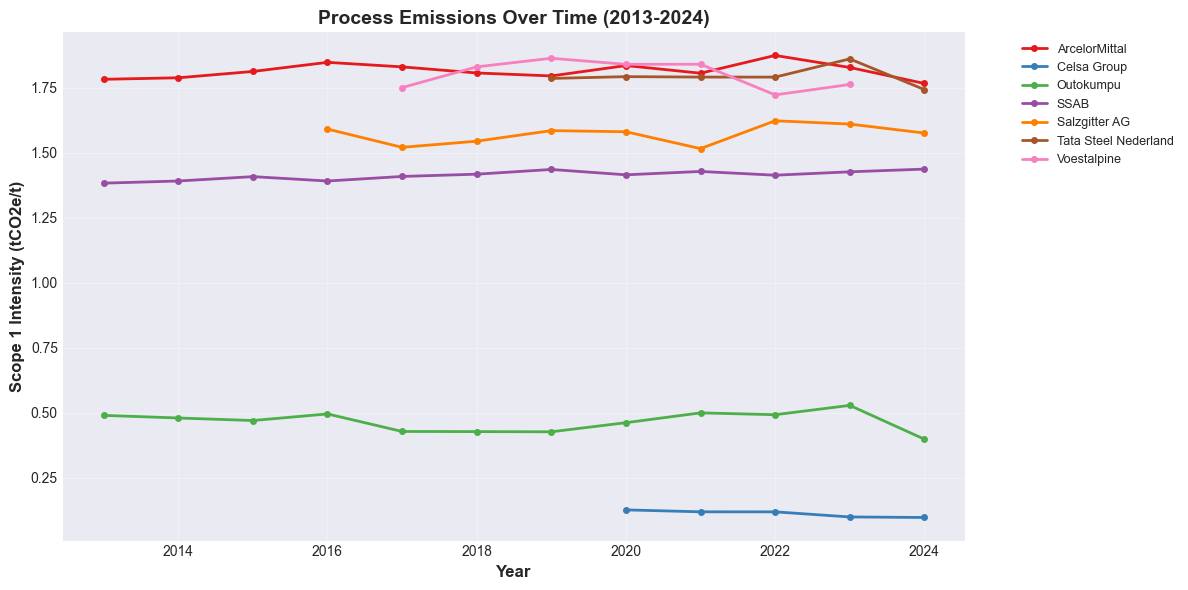


Improving: 0 companies
Stable: 7 companies
Worsening: 0 companies


In [9]:
# 1. Time series plot
fig, ax = plt.subplots(figsize=(12, 6))

# Define distinct colors for each company (avoids similar colors)
color_map = {
    'ArcelorMittal': '#e41a1c',        # Red
    'Celsa Group': '#377eb8',          # Blue
    'Outokumpu': '#4daf4a',            # Green
    'SSAB': '#984ea3',                 # Purple
    'Salzgitter AG': '#ff7f00',        # Orange
    'Tata Steel Nederland': '#a65628', # Brown
    'Voestalpine': '#f781bf',          # Pink
    'ArcelorMittal Europe': '#999999'  # Gray
}

# Plot each company's time series
for company in df_complete['company'].unique():
    # Filter to one company and sort by year
    company_data = df_complete[df_complete['company'] == company].sort_values('year')
    
    # Get color for this company (default to black if not in map)
    color = color_map.get(company, 'black')
    
    # Plot line with markers
    ax.plot(company_data['year'], company_data['intensity_scope1'], 
           marker='o', label=company, linewidth=2, markersize=4, color=color)

ax.set_xlabel('Year', fontsize=12, fontweight='bold')
ax.set_ylabel('Scope 1 Intensity (tCO2e/t)', fontsize=12, fontweight='bold')
ax.set_title('Process Emissions Over Time (2013-2024)', fontsize=14, fontweight='bold')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('plot2_trends_by_company.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nImproving: {len(trends_df[trends_df['annual_change'] < -0.01])} companies")
print(f"Stable: {len(trends_df[abs(trends_df['annual_change']) <= 0.01])} companies")
print(f"Worsening: {len(trends_df[trends_df['annual_change'] > 0.01])} companies")

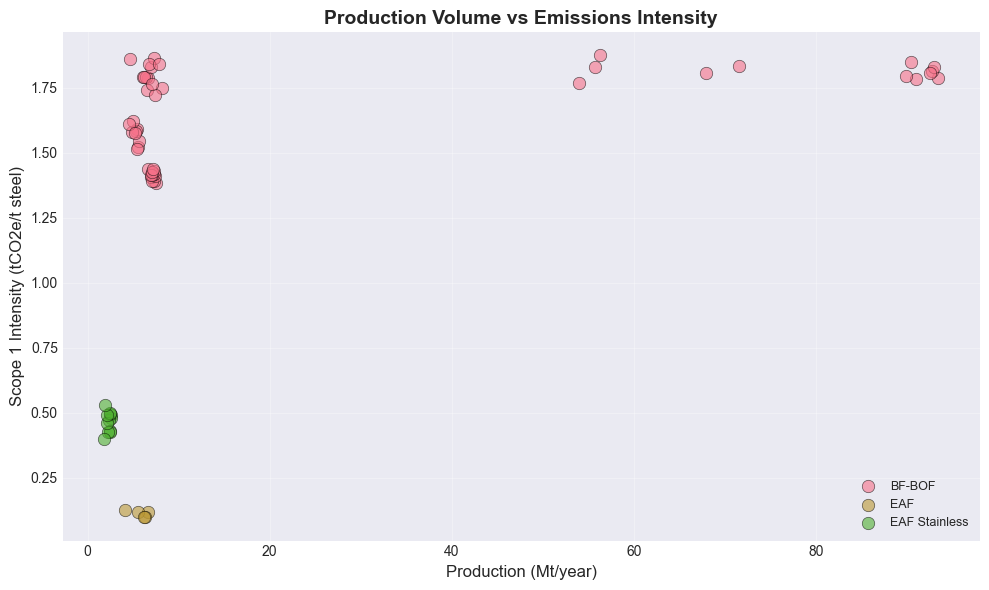

✓ Saved: plot3_production_vs_intensity.png


In [10]:
# 2. Production vs Intensity scatter
fig, ax = plt.subplots(figsize=(10, 6))

for tech in df_complete['technology'].unique():
    tech_df = df_complete[df_complete['technology'] == tech]
    ax.scatter(tech_df['production'], tech_df['intensity_scope1'],
              label=tech, s=80, alpha=0.6, edgecolors='black', linewidth=0.5)

ax.set_xlabel('Production (Mt/year)', fontsize=12)
ax.set_ylabel('Scope 1 Intensity (tCO2e/t steel)', fontsize=12)
ax.set_title('Production Volume vs Emissions Intensity', fontsize=14, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('plot3_production_vs_intensity.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Saved: plot3_production_vs_intensity.png")

## 5. Scope 1+2 Comparison: Where Is Improvement Coming From?

Compare process emissions (Scope 1) vs total emissions (Scope 1+2) to understand role of electricity/grid decarbonization.

In [11]:
# Create Scope 1+2 intensity
df['scope2_combined'] = df['scope2_location'].fillna(df['scope2_market'])
df['scope_1_2_combined'] = df['scope_1_2_location'].fillna(df['scope1'] + df['scope2_combined'])
df['intensity_scope1_2'] = df['scope_1_2_combined'] / df['production']

df_complete_1_2 = df[df['intensity_scope1_2'].notna()].copy()

print(f"Complete Scope 1+2 data: {len(df_complete_1_2)} observations")
print(f"Companies: {df_complete_1_2['company'].nunique()}")

Complete Scope 1+2 data: 70 observations
Companies: 8


In [12]:
# Calculate Scope 1+2 trends
# same code as in section 4., now with scope 1+2
trends_1_2 = []

for company in df_complete_1_2['company'].unique():
    company_df = df_complete_1_2[df_complete_1_2['company'] == company].sort_values('year')
    valid_rows = company_df[['year', 'intensity_scope1_2']].notna().all(axis=1)
    company_clean = company_df[valid_rows]
    
    if len(company_clean) >= 3:
        x = company_clean['year'].values.astype(float)
        y = company_clean['intensity_scope1_2'].values.astype(float)
        
        if not (np.any(np.isnan(x)) or np.any(np.isnan(y))):
            slope, _, r_value, p_value, _ = stats.linregress(x, y)
            trends_1_2.append({
                'company': company,
                'scope1+2_trend': round(slope, 4)
            })

trends_1_2_df = pd.DataFrame(trends_1_2)

# Merge with Scope 1 trends
comparison = trends_1_2_df.merge(
    trends_df[['company', 'annual_change']].rename(columns={'annual_change': 'scope1_trend'}),
    on='company', how='left'
)
comparison['scope2_contribution'] = comparison['scope1+2_trend'] - comparison['scope1_trend']

print("\nScope 1 vs Scope 1+2 Comparison:")
print(comparison[['company', 'scope1_trend', 'scope1+2_trend', 'scope2_contribution']].to_string(index=False))
comparison.to_csv('output_scope1_vs_scope1+2.csv', index=False)


Scope 1 vs Scope 1+2 Comparison:
             company  scope1_trend  scope1+2_trend  scope2_contribution
       ArcelorMittal        0.0014         -0.0043              -0.0057
ArcelorMittal Europe           NaN         -0.0114                  NaN
         Celsa Group       -0.0078         -0.0010               0.0068
           Outokumpu       -0.0010         -0.0364              -0.0354
                SSAB        0.0041          0.0004              -0.0037
       Salzgitter AG        0.0049         -0.0023              -0.0072
Tata Steel Nederland       -0.0003          0.0053               0.0056
         Voestalpine       -0.0072         -0.0143              -0.0071


### 5.1. Visualizations

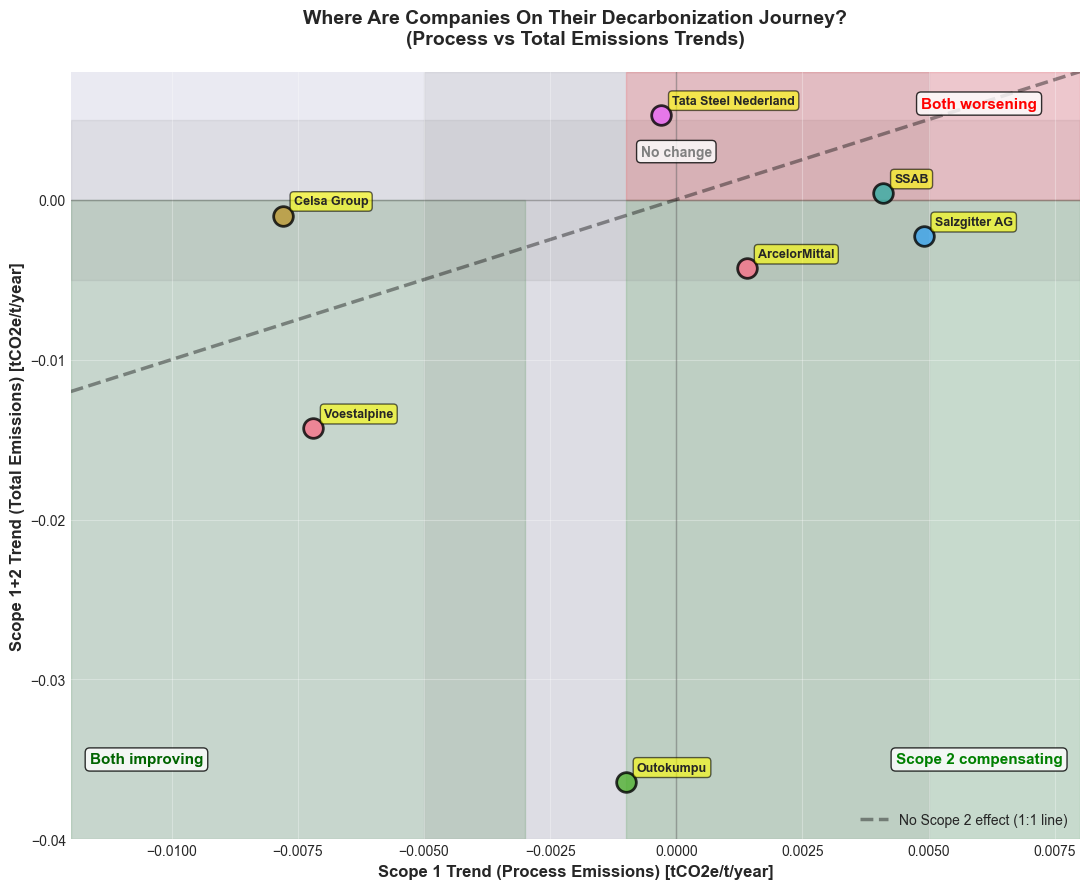


✓ Saved: plot4_process_vs_total_trends.png

Reading the plot:
• Points BELOW the diagonal = Scope 2 helping (grid decarbonization)
• Points ON the diagonal = No Scope 2 effect
• Bottom-left quadrant = Best performers (both improving)
• Center = Technological lock-in (stable emissions)


In [13]:
# 1. Scatter plot: Process vs Total emissions trends (clearer version)
fig, ax = plt.subplots(figsize=(11, 9))

# Define quadrants with clear visual regions
# Bottom-left (GOOD): Process improving AND total improving
ax.axhspan(-0.04, 0, xmin=0, xmax=0.45, alpha=0.15, color='darkgreen', zorder=0)
ax.text(-0.0105, -0.035, 'Both improving', fontsize=11, fontweight='bold', 
        color='darkgreen', ha='center', va='center', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# Bottom-right (GOOD): Total improving despite process stable/worsening = Scope 2 helping
ax.axhspan(-0.04, 0, xmin=0.55, xmax=1, alpha=0.15, color='green', zorder=0)
ax.text(0.006, -0.035, 'Scope 2 compensating', fontsize=11, fontweight='bold', 
        color='green', ha='center', va='center', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# Center (NEUTRAL): Both stable
ax.axhspan(-0.005, 0.005, alpha=0.12, color='gray', zorder=0)
ax.axvspan(-0.005, 0.005, alpha=0.12, color='gray', zorder=0)
ax.text(0, 0.003, 'No change', fontsize=10, fontweight='bold', 
        color='gray', ha='center', va='center', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# Top-right (BAD): Both worsening
ax.axhspan(0, 0.008, xmin=0.55, xmax=1, alpha=0.15, color='red', zorder=0)
ax.text(0.006, 0.006, 'Both worsening', fontsize=11, fontweight='bold', 
        color='red', ha='center', va='center', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# Reference line: Scope 1 = Scope 1+2 (no Scope 2 effect)
ax.plot([-0.012, 0.008], [-0.012, 0.008], 'k--', linewidth=2.5, alpha=0.4, 
        label='No Scope 2 effect (1:1 line)', zorder=1)

# Zero lines
ax.axhline(0, color='black', linestyle='-', linewidth=1, alpha=0.3, zorder=1)
ax.axvline(0, color='black', linestyle='-', linewidth=1, alpha=0.3, zorder=1)

# Plot companies
comparison_plot = comparison[comparison['scope1_trend'].notna()].copy()

for idx, row in comparison_plot.iterrows():
    ax.scatter(row['scope1_trend'], row['scope1+2_trend'], 
              s=200, alpha=0.8, edgecolors='black', linewidth=2, zorder=3)
    
    # Company labels
    ax.annotate(row['company'], 
               xy=(row['scope1_trend'], row['scope1+2_trend']),
               xytext=(8, 8), textcoords='offset points',
               fontsize=9, fontweight='bold', zorder=4,
               bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.6, edgecolor='black'))

# Labels and formatting
ax.set_xlabel('Scope 1 Trend (Process Emissions) [tCO2e/t/year]', fontsize=12, fontweight='bold')
ax.set_ylabel('Scope 1+2 Trend (Total Emissions) [tCO2e/t/year]', fontsize=12, fontweight='bold')
ax.set_title('Where Are Companies On Their Decarbonization Journey?\n(Process vs Total Emissions Trends)', 
            fontsize=14, fontweight='bold', pad=20)

ax.set_xlim(-0.012, 0.008)
ax.set_ylim(-0.04, 0.008)
ax.grid(True, alpha=0.3, zorder=0)
ax.legend(loc='lower right', fontsize=10, framealpha=0.9)

plt.tight_layout()
plt.savefig('plot4_process_vs_total_trends.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Saved: plot4_process_vs_total_trends.png")
print("\nReading the plot:")
print("• Points BELOW the diagonal = Scope 2 helping (grid decarbonization)")
print("• Points ON the diagonal = No Scope 2 effect")
print("• Bottom-left quadrant = Best performers (both improving)")
print("• Center = Technological lock-in (stable emissions)")


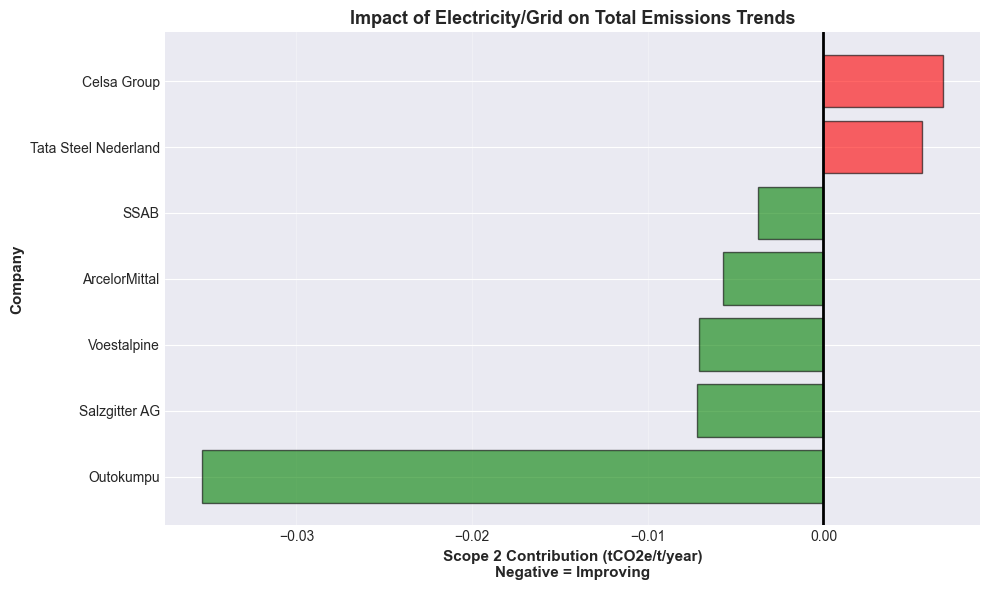


Average Scope 2 contribution: -0.0067 tCO2e/t/year


In [14]:
# 2. Scope 2 contribution
fig, ax = plt.subplots(figsize=(10, 6))

comparison_plot = comparison[comparison['scope2_contribution'].notna()].sort_values('scope2_contribution')
colors = ['green' if x < 0 else 'red' for x in comparison_plot['scope2_contribution']]

ax.barh(comparison_plot['company'], comparison_plot['scope2_contribution'], 
        color=colors, alpha=0.6, edgecolor='black')
ax.axvline(0, color='black', linewidth=2)
ax.set_xlabel('Scope 2 Contribution (tCO2e/t/year)\nNegative = Improving', fontsize=11, fontweight='bold')
ax.set_ylabel('Company', fontsize=11, fontweight='bold')
ax.set_title('Impact of Electricity/Grid on Total Emissions Trends', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig('plot3_scope2_contribution.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nAverage Scope 2 contribution: {comparison['scope2_contribution'].mean():.4f} tCO2e/t/year")

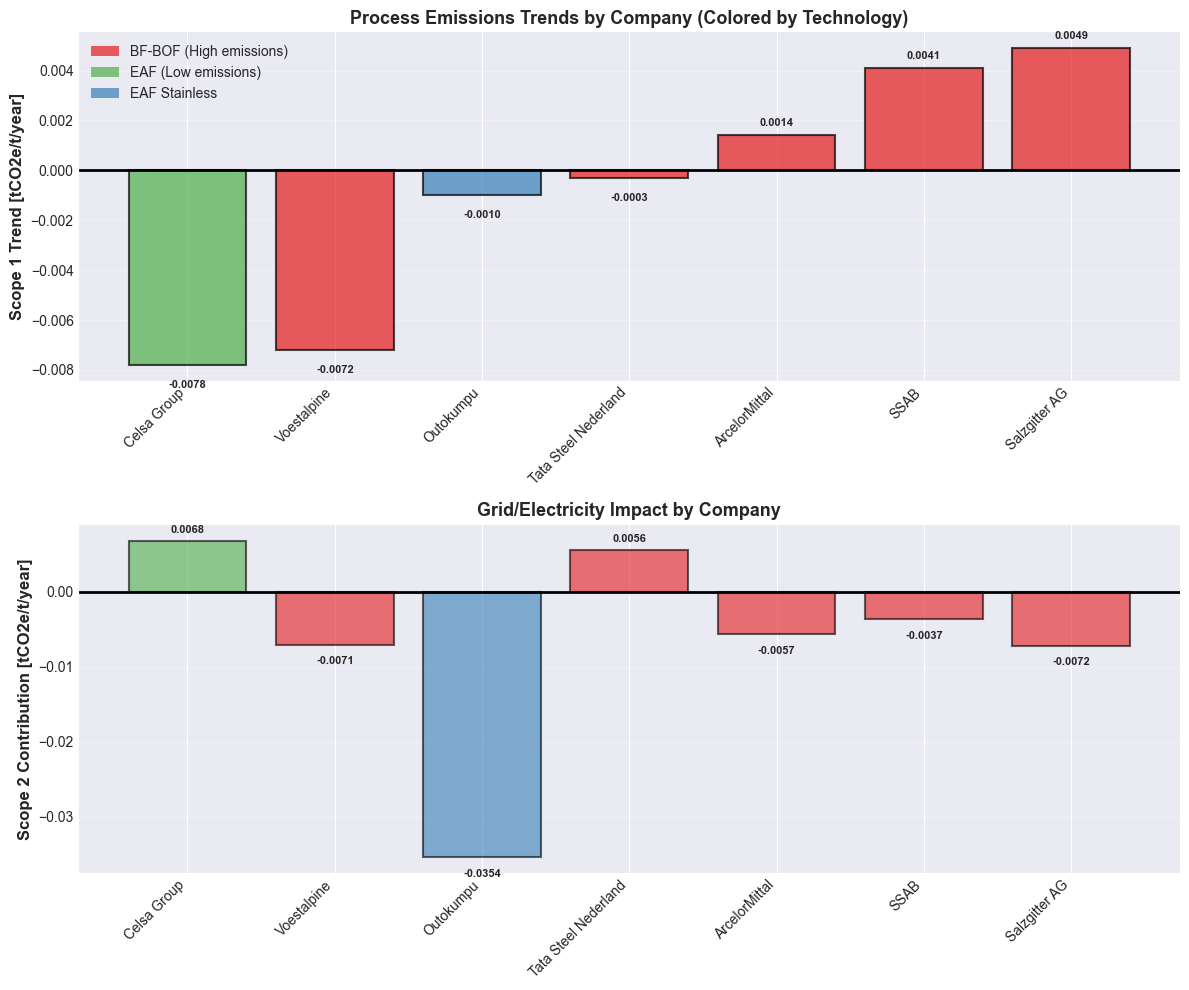


✓ Saved: plot5_company_trends_by_technology.png


In [15]:
# 3. Company-level trends colored by technology (stacked vertically)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

# Define technology colors
tech_colors = {
    'BF-BOF': '#e41a1c',           # Red (carbon-intensive)
    'EAF': '#4daf4a',              # Green (clean)
    'EAF Stainless': '#377eb8'    # Blue (stainless)
}

# Prepare data: merge technology info into comparison
comparison_with_tech = comparison[comparison['scope1_trend'].notna()].copy()
comparison_with_tech = comparison_with_tech.merge(
    df_complete[['company', 'technology']].drop_duplicates(),
    on='company', how='left'
)

# Sort by Scope 1 trend
comparison_with_tech = comparison_with_tech.sort_values('scope1_trend')

# Plot 1: Scope 1 trends by company
companies = comparison_with_tech['company']
x_pos = np.arange(len(companies))
colors1 = [tech_colors.get(tech, 'gray') for tech in comparison_with_tech['technology']]

bars1 = ax1.bar(x_pos, comparison_with_tech['scope1_trend'], 
               color=colors1, alpha=0.7, edgecolor='black', linewidth=1.5)

ax1.axhline(0, color='black', linewidth=2)
ax1.set_xticks(x_pos)
ax1.set_xticklabels(companies, rotation=45, ha='right', fontsize=10)
ax1.set_ylabel('Scope 1 Trend [tCO2e/t/year]', fontsize=12, fontweight='bold')
ax1.set_title('Process Emissions Trends by Company (Colored by Technology)', fontsize=13, fontweight='bold')
ax1.grid(True, alpha=0.3, axis='y')

# Add value labels
for bar, val in zip(bars1, comparison_with_tech['scope1_trend']):
    height = bar.get_height()
    label_y = height + 0.0003 if height >= 0 else height - 0.0006
    ax1.text(bar.get_x() + bar.get_width()/2., label_y,
            f'{val:.4f}', ha='center', va='bottom' if height >= 0 else 'top',
            fontsize=8, fontweight='bold')

# Legend for technologies
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=tech_colors['BF-BOF'], label='BF-BOF (High emissions)', alpha=0.7),
                  Patch(facecolor=tech_colors['EAF'], label='EAF (Low emissions)', alpha=0.7),
                  Patch(facecolor=tech_colors['EAF Stainless'], label='EAF Stainless', alpha=0.7)]
ax1.legend(handles=legend_elements, loc='upper left', fontsize=10)

# Plot 2: Scope 2 contribution by company (same order)

bars2 = ax2.bar(x_pos, comparison_with_tech['scope2_contribution'],
               color=colors1, alpha=0.6, edgecolor='black', linewidth=1.5)

ax2.axhline(0, color='black', linewidth=2)
ax2.set_xticks(x_pos)
ax2.set_xticklabels(companies, rotation=45, ha='right', fontsize=10)
ax2.set_ylabel('Scope 2 Contribution [tCO2e/t/year]', fontsize=12, fontweight='bold')
ax2.set_title('Grid/Electricity Impact by Company', fontsize=13, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')

# Add value labels
for bar, val in zip(bars2, comparison_with_tech['scope2_contribution']):
    height = bar.get_height()
    label_y = height + 0.0008 if height >= 0 else height - 0.0015
    ax2.text(bar.get_x() + bar.get_width()/2., label_y,
            f'{val:.4f}', ha='center', va='bottom' if height >= 0 else 'top',
            fontsize=8, fontweight='bold')

plt.tight_layout()
plt.savefig('plot5_company_trends_by_technology.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Saved: plot5_company_trends_by_technology.png")

## 6. Key Findings

**Technology "Lock-In":**  
Process emissions (Scope 1) show minimal change across 2013-2024, with trends ranging from -0.0078 to +0.0049 tCO2e/t/year. Most companies (7/7) are classified as stable (±0.01/year threshold). Technology choice determines 90%+ of emissions, while annual changes are negligible.

**Grid Decarbonization:**  
Where total emissions (Scope 1+2) are declining, improvements primarily come from Scope 2 (electricity/grid decarbonization), not process changes.

**Interpretation:**  
Real decarbonization requires technology transformation (H₂-DRI, EAF), not incremental optimization of current processes.

In [16]:
# Summary statistics
print("="*60)
print("SUMMARY STATISTICS")
print("="*60)

print("\n1. TECHNOLOGY DOMINATES:")
print(f"   Range: {tech_stats['mean'].min():.2f} - {tech_stats['mean'].max():.2f} tCO₂e/t")
print(f"   Difference: {tech_stats['mean'].max()/tech_stats['mean'].min():.0f}x")

print("\n2. SCOPE 1 TRENDS (Process Emissions):")
print(f"   Improving (<-0.01/year): {len(trends_df[trends_df['annual_change'] < -0.01])} companies")
print(f"   Stable (±0.01/year): {len(trends_df[abs(trends_df['annual_change']) <= 0.01])} companies")
print(f"   Worsening (>+0.01/year): {len(trends_df[trends_df['annual_change'] > 0.01])} companies")

print("\n3. SCOPE 2 CONTRIBUTION (Grid Effect):")
print(f"   Average: {comparison['scope2_contribution'].mean():.4f} tCO₂e/t/year")
print(f"   Interpretation: Negative = Grid helping reduce total emissions")

print("\n" + "="*60)

SUMMARY STATISTICS

1. TECHNOLOGY DOMINATES:
   Range: 0.11 - 1.66 tCO₂e/t
   Difference: 15x

2. SCOPE 1 TRENDS (Process Emissions):
   Improving (<-0.01/year): 0 companies
   Stable (±0.01/year): 7 companies
   Worsening (>+0.01/year): 0 companies

3. SCOPE 2 CONTRIBUTION (Grid Effect):
   Average: -0.0067 tCO₂e/t/year
   Interpretation: Negative = Grid helping reduce total emissions



## 7. Save Outputs

In [ ]:
# Save working dataset
df.to_csv('output_working_dataset_with_intensities.csv', index=False)

print("✓ Saved outputs:")
print("  • output_stats_by_technology.csv")
print("  • output_trends_scope1.csv")
print("  • output_scope1_vs_scope1+2.csv")
print("  • output_working_dataset_with_intensities.csv")
print("  • plot1_boxplot_technology.png")
print("  • plot2_trends_by_company.png")
print("  • plot3_scope2_contribution.png")

---

## Next Steps

* **External factors integration** (carbon price, coal price, EU ETS benchmarking)
* **Case studies** (including country-specific external drivers)
* **Action Scores calculation** (0-100 composite metric)